# **AdaBoost**

AdaBoost (Adaptive Boosting) es un algoritmo de Machine Learning que sirve para realizar tareas de clasificación. Su objetivo es aprender a identificar patrones en los datos para poder predecir correctamente a qué grupo pertenece una observación.

La idea principal de AdaBoost es muy sencilla: en lugar de utilizar un solo modelo para tomar decisiones, combina muchos modelos pequeños y simples para construir uno más preciso.

Cada modelo aprende de los errores cometidos por el anterior. Si una observación fue clasificada incorrectamente, AdaBoost le presta más atención en la siguiente iteración para intentar corregir ese error. Al final, todos los modelos trabajan juntos para obtener una mejor predicción.



**Árboles de decisión**

AdaBoost necesita un modelo base para comenzar a aprender. En este proyecto se utilizan árboles de decisión porque son fáciles de entender y permiten encontrar reglas para clasificar los datos.

Por ejemplo, un árbol podría aprender reglas como:

Si el peso es muy alto y la longitud de la aleta es grande, probablemente sea un pingüino Gentoo.
Si el pico es más corto, probablemente sea un Adelie.

Sin embargo, un solo árbol puede equivocarse. Por eso AdaBoost combina muchos árboles pequeños y utiliza los errores de unos para mejorar los siguientes.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pinwinos = pd.read_csv('PinwinosPalmerLimpia.csv')
pinwinos.head()


,Especie,Isla,Sexo,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
0,Adelie,Torgersen,Macho,2007,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Hembra,2007,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Hembra,2007,4.03,1.80,19.5,3.25
3,Adelie,Torgersen,Hembra,2007,3.88,1.83,19.0,3.70
4,Adelie,Torgersen,Hembra,2007,3.67,1.93,19.3,3.45


In [ ]:
# División de datos
from sklearn.model_selection import train_test_split

# Codificación de variables - convierte las variables de categoricas a vaores númericos
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo Adaboost
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Métricas para evaluar el modelo
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

En este paso se prepararon los datos para que pudieran ser utilizados por el modelo AdaBoost. Como el modelo no puede trabajar directamente con texto, las variables categóricas como sexo, isla y especie se transformaron a valores numéricos. De esta manera, toda la información quedó en un formato adecuado para el entrenamiento del modelo.

In [ ]:
# Convertimos Sexo e Isla
df_modelo = pd.get_dummies(pinwinos, columns=["Sexo", "Isla"], drop_first=True)

# Convertimos True/False a 0/1
for col in df_modelo.select_dtypes(include="bool").columns:
    df_modelo[col] = df_modelo[col].astype(int)

# Codificamos la variable objetivo
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_modelo["Especie_num"] = encoder.fit_transform(df_modelo["Especie"])

# Mostramos la correspondencia entre especies y códigos
equivalencias = pd.DataFrame({
    "Especie": encoder.classes_,
    "Especie_num": range(len(encoder.classes_))
})

print(equivalencias)


     Especie  Especie_num
0     Adelie            0
1  Chinstrap            1
2     Gentoo            2


Una vez transformados los datos, se definieron las variables predictoras y la variable objetivo. Las variables predictoras contienen la información que utilizará el modelo para realizar las predicciones, mientras que la variable objetivo corresponde a la especie del pingüino, que es la categoría que se desea clasificar.

In [ ]:
# Variables predictoras
X = df_modelo[[
    "Longitud_Pico_cm",
    "Profundidad_Pico_cm",
    "Longitud_Aleta_cm",
    "Masa_Corporal_kg",
    "Sexo_Macho",
    "Isla_Dream",
    "Isla_Torgersen"
]]

# Variable objetivo
y = df_modelo["Especie_num"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print("Especie_num")

Variables predictoras:
['Longitud_Pico_cm', 'Profundidad_Pico_cm', 'Longitud_Aleta_cm', 'Masa_Corporal_kg', 'Sexo_Macho', 'Isla_Dream', 'Isla_Torgersen']

Variable objetivo:
Especie_num


En esta etapa dividí la base de datos en dos conjuntos. El 80% de los datos se utilizó para entrenar el modelo AdaBoost y el 20% restante se reservó para evaluar su desempeño. Además, utilicé el parámetro stratify para asegurar que las tres especies de pingüinos mantuvieran una proporción similar tanto en el conjunto de entrenamiento como en el de prueba, evitando sesgos en los resultados.

In [ ]:
# ============================
# División de los datos
# ============================

from sklearn.model_selection import train_test_split

# Se divide la base de datos en:
# 80% para entrenamiento
# 20% para prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Mostramos las dimensiones de cada conjunto
print("Dimensiones de los conjuntos de datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Dimensiones de los conjuntos de datos:
X_train: (275, 8)
X_test: (69, 8)
y_train: (275,)
y_test: (69,)


**Construcción del modelo AdaBoost**

Se construye el modelo AdaBoost. Este algoritmo combina múltiples árboles de decisión pequeños para generar un clasificador más fuerte. Cada árbol aprende de los errores cometidos por los anteriores, mejorando progresivamente las predicciones.

Se utilizan arboles con una profundidad máxima de dos niveles. Esto permite que sean modelos simples o clasificadores débiles, que es precisamente lo que necesita AdaBoost para funcionar correctamente.

El modelo entrenará 100 árboles de decisión. Cada uno contribuirá a mejorar el resultado final.

La influencia de cada árbol dentro del modelo final es un valor de 0.5 permite que el aprendizaje sea más gradual y estable.

Y hacemos que el parámetro garantice que los resultados puedan reproducirse exactamente si se vuelve a ejecutar el código.


In [ ]:
modelo = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=2
    ),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

En esta etapa se entrena el modelo utilizando los datos de entrenamiento. Aquí el algoritmo aprende patrones entre las variables predictoras y la variable objetivo, ajustando los árboles de decisión para mejorar sus predicciones.

In [ ]:
modelo.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.5, n_estimators=100, random_state=42)

Se realizan las predicciones utilizando el modelo ya entrenado. El modelo toma los datos de prueba y predice la clase correspondiente para cada registro.

Después, se calcula el accuracy, que es una métrica que nos indica qué porcentaje de predicciones fueron correctas al comparar los valores reales con los valores predichos. Esto nos permite evaluar el desempeño general del modelo y saber qué tan bien está funcionando

In [ ]:
y_pred = modelo.predict(X_test)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9855072463768116


El **Classification Report** muestra qué tan bien clasificó el modelo cada una de las especies de pingüinos utilizando tres métricas principales:



*  **Precision (Precisión):** De todas las veces que el modelo predijo una especie, cuántas fueron correctas.

* **Recall (Sensibilidad):** De todos los individuos reales de una especie, cuántos logró identificar correctamente.

* **F1-Score:** Es una combinación entre Precision y Recall. Mientras más cercano a 1, mejor desempeño tiene el modelo.

* **Support:** Cantidad de observaciones de cada especie en el conjunto de prueba.


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



La matriz de confusión muestra el desempeño del modelo comparando los valores reales con las predicciones. La diagonal representa los aciertos del modelo, mientras que los valores fuera de ella indican los errores de clasificación. Esto permite analizar de forma clara en qué casos el modelo clasifica correctamente y en cuáles se equivoca.

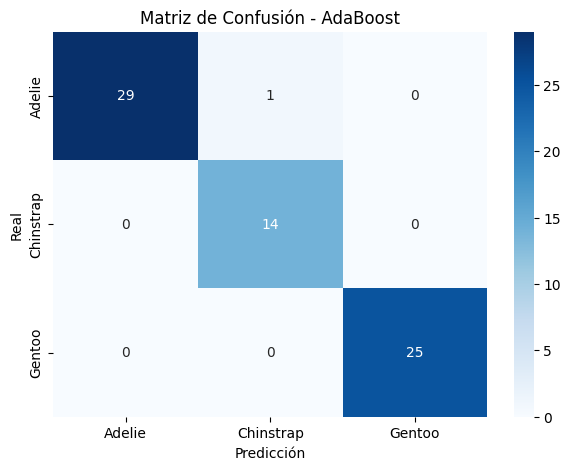

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',   # 🔵 colores azules
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - AdaBoost")

plt.show()

### **Conclusiones**

En este trabajo se utilizó el modelo AdaBoost para clasificar especies de pingüinos a partir de sus características físicas. Los resultados muestran un accuracy alto y buenas métricas de desempeño, lo que indica que el modelo logra clasificar correctamente la mayoría de los casos.

Sin embargo, estos resultados también se ven influenciados por la naturaleza de los datos, ya que las variables están muy bien separadas entre las especies. Esto hace que el modelo aprenda patrones muy específicos del conjunto de datos, más que relaciones complejas.

Por lo tanto, el desempeño obtenido depende tanto del modelo como de la estructura de la base de datos, que es más descriptiva que predictiva en escenarios reales más complejos.